# Классификация: IC50 выше медианы выборки

Цель ноутбука - построить и сравнить несколько моделей бинарной классификации для задачи: превышает ли значение IC50, mM медианное значение выборки.

Используются результаты preprocessing:

- SF_ML_data_tree.pkl - набор признаков после удаления константных и высококоррелированных признаков, предназначенный для tree-based моделей;
- SF_ML_data_linear.pkl - набор признаков после дополнительной VIF-редукции, предназначенный для линейных моделей.

При моделировании из признакового пространства исключаются все целевые переменные: IC50, mM, CC50, mM и SI. Это необходимо для предотвращения утечки данных: модель должна обучаться только на исходных молекулярных признаках, то есть RDKit-дескрипторах.

Поскольку порогом является медиана IC50, классы ожидаемо близки к сбалансированным. Поэтому основной метрикой выбирается ROC_AUC, а F1, precision, recall, accuracy и PR_AUC используются как дополнительные метрики.

In [ ]:
import os
import joblib
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')

In [42]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 5

TARGET_SOURCE = 'IC50, mM'
TARGET_NAME = 'IC50_gt_median'
TARGET_COLS = ['IC50, mM', 'CC50, mM', 'SI']

MODELS_DIR = 'models'

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 120)

## Загрузка подготовленных данных

In [43]:
def load_dataset(filename):
    return pd.read_pickle(f'{filename}.pkl')


df_tree = load_dataset('SF_ML_data_tree')
df_linear = load_dataset('SF_ML_data_linear')

print('df_tree shape:', df_tree.shape)
print('df_linear shape:', df_linear.shape)

display(df_tree.head())

df_tree shape: (966, 148)
df_linear shape: (966, 100)


,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,MaxPartialCharge,MinPartialCharge,FpDensityMorgan1,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,Ipc,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA7,SlogP_VSA8,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,...,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_Ndealkylation1,fr_Ndealkylation2,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azo,fr_bicyclic,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_ketone,fr_ketone_Topliss,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_piperdine,fr_piperzine,fr_priamide,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea,"IC50, mM","CC50, mM",SI
0,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,0.038844,-0.293526,0.642857,14.822266,9.700470,2.600532,-2.343082,2.644698,-2.322229,5.944519,0.193481,3.150503,1.164038,2.187750e+06,0.000000,0.0,0.0,0.0,0.0,0.0,9.984809,0.0,0.0,0.0,54.384066,74.032366,35.342864,0.000000,0.000000,11.423370,0.0,0.000000,43.480583,105.750639,13.089513,0.00000,0.0,0.000000,0.000000,0.0,24.512883,0.000000,33.495774,105.750639,0.0,0.0,24.72,0.0,0.0,0.0,0.000000,21.659962,24.925325,64.208216,...,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,6.239374,175.482382,28.125000
1,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,0.012887,-0.313407,0.607143,14.975110,9.689226,2.614066,-2.394690,2.658342,-2.444817,5.134527,0.120322,3.150503,1.080362,2.187750e+06,10.633577,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,54.384066,97.951860,12.083682,0.000000,0.000000,0.000000,0.0,10.633577,33.495774,117.834321,13.089513,0.00000,0.0,10.633577,0.000000,0.0,25.173194,0.000000,33.495774,105.750639,0.0,0.0,24.06,0.0,0.0,0.0,0.000000,21.659962,23.919494,77.297729,...,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0.771831,5.402819,7.000000
2,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,0.094802,-0.325573,0.562500,15.353938,9.681293,2.665274,-2.477203,2.679014,-2.565224,5.117187,-0.922902,3.214947,1.219066,8.610751e+06,8.966062,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,41.542423,74.032366,23.671624,53.363882,8.966062,0.000000,0.0,0.000000,33.495774,117.834321,41.280201,0.00000,0.0,0.000000,0.000000,0.0,62.329944,0.000000,33.495774,105.750639,0.0,0.0,0.00,0.0,0.0,0.0,0.000000,21.659962,23.919494,86.263791,...,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,3,0,223.808778,161.142320,0.720000
3,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,0.038844,-0.293526,0.620690,14.821216,9.700497,2.600529,-2.342885,2.644709,-2.322030,5.944502,0.193510,3.179270,1.120513,3.572142e+06,0.000000,0.0,0.0,0.0,0.0,0.0,9.984809,0.0,0.0,0.0,60.804888,74.032366,35.342864,0.000000,0.000000,11.423370,0.0,0.000000,43.480583,112.171461,13.089513,0.00000,0.0,0.000000,0.000000,0.0,24.512883,0.000000,33.495774,112.171461,0.0,0.0,24.72,0.0,0.0,0.0,0.000000,21.659962,24.925325,70.629038,...,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,1.705624,107.855654,63.235294
4,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,0.062897,-0.257239,0.600000,14.831112,9.700386,2.602486,-2.342009,2.64847

## Формирование бинарной целевой переменной и признаков

Порог классификации задаётся как медиана IC50, mM по подготовленной выборке. Положительный класс 1 означает, что значение IC50 выше медианы выборки.

In [44]:
THRESHOLD = df_tree[TARGET_SOURCE].median()

print('Порог IC50 median:', THRESHOLD)


def split_features_and_target(df):
    X = df[[col for col in df.columns if col not in TARGET_COLS]].copy()
    y = (df[TARGET_SOURCE] > THRESHOLD).astype(int).copy()
    return X, y


X_tree, y_tree = split_features_and_target(df_tree)
X_linear, y_linear = split_features_and_target(df_linear)

assert y_tree.equals(y_linear), 'Целевая переменная в df_tree и df_linear отличается.'
assert X_tree.index.equals(y_tree.index), 'Индексы X_tree и y_tree не совпадают.'
assert X_linear.index.equals(y_linear.index), 'Индексы X_linear и y_linear не совпадают.'
assert X_tree.index.equals(X_linear.index), 'Индексы X_tree и X_linear не совпадают.'

y = y_tree.copy()

print('X_tree:', X_tree.shape)
print('X_linear:', X_linear.shape)
print('y:', y.shape)

display(
    y.value_counts()
     .rename_axis('class')
     .reset_index(name='count')
     .assign(share=lambda x: x['count'] / x['count'].sum())
)

Порог IC50 median: 45.222782515106104
X_tree: (966, 145)
X_linear: (966, 97)
y: (966,)


,class,count,share
0,0,483,0.5
1,1,483,0.5


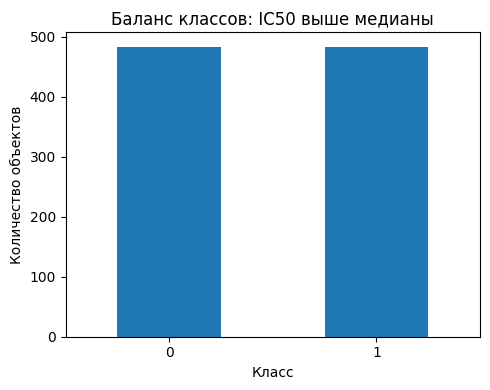

In [45]:
plt.figure(figsize=(5, 4))
y.value_counts().sort_index().plot(kind='bar')
plt.title('Баланс классов: IC50 выше медианы')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Баланс классов

Целевая переменная сформирована как индикатор того, превышает ли IC50 медианное значение выборки. Так как порогом является медиана, классы получились практически сбалансированными: количество объектов классов 0 и 1 почти одинаковое.

Такой баланс удобен для моделирования: accuracy можно интерпретировать напрямую, balanced_accuracy близка к обычной accuracy, а precision, recall и F1 не искажаются доминированием одного класса. Поэтому специальные методы борьбы с дисбалансом, такие как oversampling или undersampling, для этой задачи не требуются.

Для оценки качества моделей всё равно используются несколько метрик: accuracy, balanced_accuracy, F1, ROC_AUC и PR_AUC. Основной метрикой выбрана ROC_AUC, так как она оценивает способность модели ранжировать объекты по вероятности принадлежности к положительному классу независимо от конкретного порога классификации.

## Разделение данных на train и test выборки

Разделение выполняется один раз и одинаково для X_tree и X_linear. Для классификации используется stratify=y, чтобы сохранить баланс классов в train и test.

In [46]:
train_idx, test_idx = train_test_split(
    np.arange(len(y)),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_tree_train = X_tree.iloc[train_idx].copy()
X_tree_test = X_tree.iloc[test_idx].copy()

X_linear_train = X_linear.iloc[train_idx].copy()
X_linear_test = X_linear.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print('X_tree_train:', X_tree_train.shape)
print('X_tree_test:', X_tree_test.shape)
print('X_linear_train:', X_linear_train.shape)
print('X_linear_test:', X_linear_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

print('Баланс классов train:')
print(y_train.value_counts(normalize=True).sort_index())

print('Баланс классов test:')
print(y_test.value_counts(normalize=True).sort_index())

X_tree_train: (772, 145)
X_tree_test: (194, 145)
X_linear_train: (772, 97)
X_linear_test: (194, 97)
y_train: (772,)
y_test: (194,)
Баланс классов train:
IC50, mM
0    0.5
1    0.5
Name: proportion, dtype: float64
Баланс классов test:
IC50, mM
0    0.5
1    0.5
Name: proportion, dtype: float64


## Метрики качества

Основная метрика - ROC_AUC, так как она оценивает качество ранжирования объектов по вероятности положительного класса и не зависит от конкретного порога классификации.

Дополнительно рассчитываются accuracy, balanced_accuracy, precision, recall, F1 и PR_AUC.

In [47]:
def get_positive_scores(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        return model.decision_function(X)
    return model.predict(X)


def classification_metrics(y_true, y_pred, y_score):
    return {'accuracy': accuracy_score(y_true, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_true, y_score),
            'pr_auc': average_precision_score(y_true, y_score)}


def evaluate_classifier(model, X_train, X_test, y_train, y_test, refit=True):
    if refit:
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_score = get_positive_scores(model, X_test)

    metrics = classification_metrics(y_test, y_pred, y_score)

    return metrics, y_pred, y_score

## Базовые модели

Используются две группы моделей: линейные модели обучаются на X_linear, где дополнительно снижена мультиколлинеарность с помощью VIF-редукции, а tree-based модели обучаются на X_tree, где сохранено больше признаков.

In [48]:
linear_models = {'Dummy_most_frequent': DummyClassifier(strategy='most_frequent'),
                 'LogisticRegression_L2': make_pipeline(StandardScaler(),
                                                        LogisticRegression(penalty='l2', C=1.0, max_iter=5000, 
                                                                           class_weight='balanced', random_state=RANDOM_STATE)),

                 'LogisticRegression_L1': make_pipeline(StandardScaler(),
                                                        LogisticRegression(penalty='l1', solver='liblinear', C=1.0,
                                                                           max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE)),

                 'LinearSVC': make_pipeline(StandardScaler(),
                                            LinearSVC(C=1.0, class_weight='balanced', random_state=RANDOM_STATE, max_iter=10000)),

                 'SVC_rbf': make_pipeline(StandardScaler(),
                                          SVC(kernel='rbf', C=3.0, gamma='scale', class_weight='balanced', random_state=RANDOM_STATE))}

tree_models = {'RandomForest': RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_leaf=2,
                                                      class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1),
    
               'ExtraTrees': ExtraTreesClassifier(n_estimators=500, max_depth=None, min_samples_leaf=2,
                                                  class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1),

               'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
               
               'HistGBM': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
               
               'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE),
               
               'XGBoost': XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, 
                                        colsample_bytree=0.8, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=1),
                
               'LightGBM': LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                                          colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=1, verbose=-1)}

## Кросс-валидация базовых моделей

In [49]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

scoring = {'roc_auc': 'roc_auc',
           'pr_auc': 'average_precision',
           'f1': 'f1',
           'accuracy': 'accuracy',
           'balanced_accuracy': 'balanced_accuracy'}


def get_cv_row(model_name, model, X_train, y_train, feature_set_name):
    scores = cross_validate(model,
                            X_train,
                            y_train,
                            cv=cv,
                            scoring=scoring,
                            n_jobs=4,
                            return_train_score=True)

    return {'model': model_name,
            'feature_set': feature_set_name,
            'cv_ROC_AUC_mean': scores['test_roc_auc'].mean(),
            'cv_ROC_AUC_std': scores['test_roc_auc'].std(),
            'cv_PR_AUC_mean': scores['test_pr_auc'].mean(),
            'cv_F1_mean': scores['test_f1'].mean(),
            'cv_accuracy_mean': scores['test_accuracy'].mean(),
            'cv_balanced_accuracy_mean': scores['test_balanced_accuracy'].mean(),
            'train_ROC_AUC_mean': scores['train_roc_auc'].mean(),
            'train_F1_mean': scores['train_f1'].mean()}


def run_cv_for_group(models, X_train, y_train, feature_set_name):
    return [get_cv_row(model_name, model, X_train, y_train, feature_set_name)
            for model_name, model in models.items()]


cv_rows = run_cv_for_group(linear_models, X_linear_train, y_train, 'X_linear')\
        + run_cv_for_group(tree_models, X_tree_train, y_train, 'X_tree')


cv_results = pd.DataFrame(cv_rows)\
               .sort_values('cv_ROC_AUC_mean', ascending=False)\
               .reset_index(drop=True)

cv_results['overfit_gap_ROC_AUC'] = cv_results['train_ROC_AUC_mean'] - cv_results['cv_ROC_AUC_mean']

display(cv_results.round(4))

,model,feature_set,cv_ROC_AUC_mean,cv_ROC_AUC_std,cv_PR_AUC_mean,cv_F1_mean,cv_accuracy_mean,cv_balanced_accuracy_mean,train_ROC_AUC_mean,train_F1_mean,overfit_gap_ROC_AUC
0,RandomForest,X_tree,0.7839,0.0090,0.7861,0.7132,0.7164,0.7164,0.9884,0.9527,0.2044
1,ExtraTrees,X_tree,0.7801,0.0127,0.7809,0.7078,0.7099,0.7100,0.9903,0.9508,0.2102
2,SVC_rbf,X_linear,0.7779,0.0054,0.7771,0.7118,0.7177,0.7177,0.9390,0.8634,0.1611
3,HistGBM,X_tree,0.7731,0.0195,0.7821,0.6983,0.7034,0.7034,0.9955,0.9571,0.2224
4,XGBoost,X_tree,0.7721,0.0071,0.7821,0.6891,0.6969,0.6970,0.9876,0.9421,0.2155
5,GradientBoosting,X_tree,0.7718,0.0067,0.7701,0.6778,0.6905,0.6905,0.9808,0.9300,0.2089
6,LightGBM,X_tree,0.7692,0.0088,0.7768,0.6908,0.6982,0.6982,0.9920,0.9548,0.2228
7,AdaBoost,X_tree,0.7657,0.0259,0.7591,0.6949,0.6970,0.6970,0.8671,0.7737,0.1014
8,LogisticRegression_L1,X_linear,0.7408,0.0251,0.7336,0.6799,0.6853,0.6853,0.8412,0.7557,0.1004
9,LogisticRegression_L2,X_linear,0.7385,0.0239,0.7305,0.6815,0.6905,0.6905,0.8437,0.7541,0.1053


## Оценка базовых моделей на тестовой выборке

In [50]:
fitted_baseline = {}


def get_test_result_row(model_name, model, feature_set_name, X_train, X_test, refit=True):
    metrics, y_pred, y_score = evaluate_classifier(model,
                                                   X_train,
                                                   X_test,
                                                   y_train,
                                                   y_test,
                                                   refit=refit)

    if refit:
        fitted_baseline[model_name] = model

    return {'model': model_name,
            'feature_set': feature_set_name,
            **metrics}, y_pred, y_score


model_groups = [(linear_models, 'X_linear', X_linear_train, X_linear_test),
                (tree_models, 'X_tree', X_tree_train, X_tree_test)]

test_outputs = [get_test_result_row(model_name, model, feature_set_name, X_train, X_test)
                for models, feature_set_name, X_train, X_test in model_groups
                for model_name, model in models.items()]

test_rows = [row for row, _, _ in test_outputs]

test_results = pd.DataFrame(test_rows)\
                 .sort_values('roc_auc', ascending=False)\
                 .reset_index(drop=True)

display(test_results.round(4))

,model,feature_set,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,LightGBM,X_tree,0.7165,0.7165,0.7188,0.7113,0.7150,0.8095,0.7956
1,XGBoost,X_tree,0.7423,0.7423,0.7582,0.7113,0.7340,0.8065,0.7835
2,LogisticRegression_L1,X_linear,0.7165,0.7165,0.7188,0.7113,0.7150,0.8017,0.8019
3,LogisticRegression_L2,X_linear,0.7165,0.7165,0.7188,0.7113,0.7150,0.7982,0.8000
4,ExtraTrees,X_tree,0.7216,0.7216,0.7312,0.7010,0.7158,0.7982,0.7949
5,AdaBoost,X_tree,0.7268,0.7268,0.7500,0.6804,0.7135,0.7976,0.7998
6,RandomForest,X_tree,0.7320,0.7320,0.7368,0.7216,0.7292,0.7972,0.8029
7,LinearSVC,X_linear,0.7165,0.7165,0.7283,0.6907,0.7090,0.7941,0.7966
8,SVC_rbf,X_linear,0.6959,0.6959,0.7065,0.6701,0.6878,0.7934,0.7959
9,GradientBoosting,X_tree,0.7062,0.7062,0.7128,0.6907,0.7016,0.7869,0.7924


## График сравнения моделей

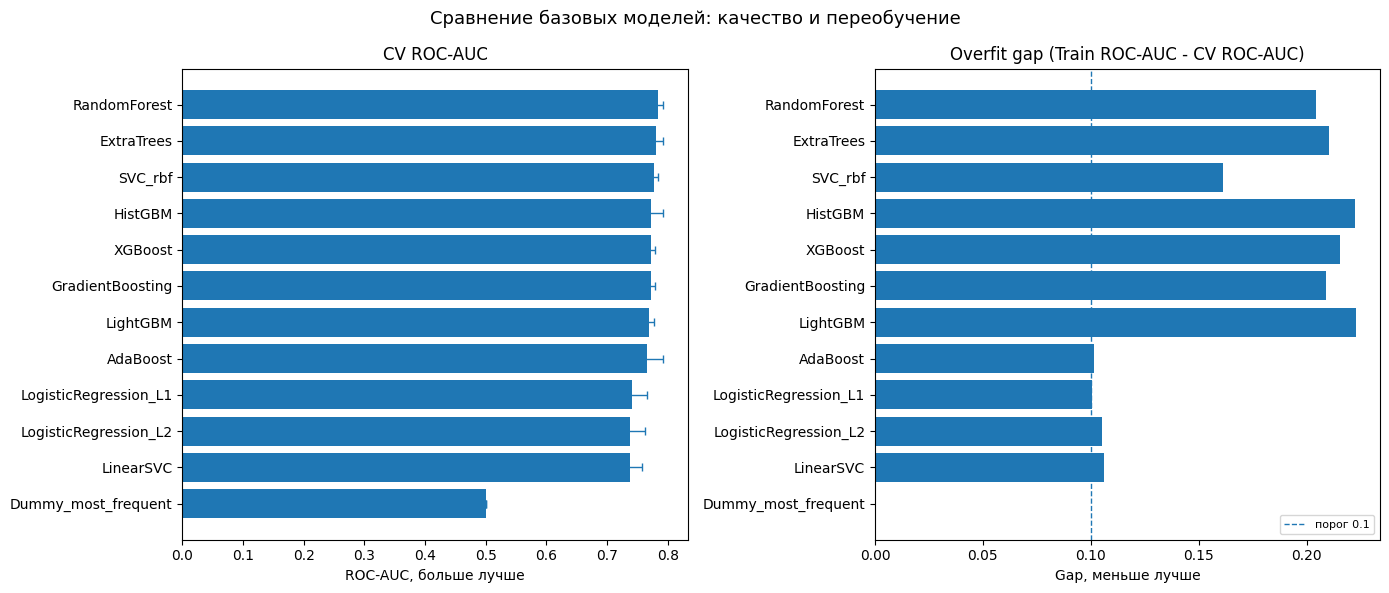

In [51]:
plot_df = cv_results.sort_values('cv_ROC_AUC_mean', ascending=True)
order = plot_df['model'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(plot_df['model'], plot_df['cv_ROC_AUC_mean'])
axes[0].errorbar(
    plot_df['cv_ROC_AUC_mean'],
    plot_df['model'],
    xerr=plot_df['cv_ROC_AUC_std'],
    fmt='none',
    capsize=3,
    linewidth=1
)
axes[0].set_title('CV ROC-AUC')
axes[0].set_xlabel('ROC-AUC, больше лучше')

gap_df = cv_results.set_index('model').reindex(order).reset_index()

axes[1].barh(gap_df['model'], gap_df['overfit_gap_ROC_AUC'])
axes[1].axvline(0.1, linestyle='--', linewidth=1, label='порог 0.1')
axes[1].set_title('Overfit gap (Train ROC-AUC - CV ROC-AUC)')
axes[1].set_xlabel('Gap, меньше лучше')
axes[1].legend(fontsize=8, loc='lower right')

plt.suptitle('Сравнение базовых моделей: качество и переобучение', fontsize=13)
plt.tight_layout()
plt.show()

## Выбор моделей для подбора гиперпараметров

Для тюнинга отобраны только наиболее перспективные модели по результатам кросс-валидации и тестовой оценки baseline-моделей.

На кросс-валидации лучшие значения ROC_AUC показали RandomForest, ExtraTrees и SVC_rbf. На тестовой выборке наиболее сильными оказались LightGBM, XGBoost и RandomForest: LightGBM показал лучший ROC_AUC, XGBoost - лучший баланс accuracy, balanced_accuracy и F1, а RandomForest - одно из лучших значений PR_AUC.

Поэтому в tuning_configs включены LogisticRegression, SVC_rbf, RandomForest, ExtraTrees, XGBoost и LightGBM. LogisticRegression оставлена как сильная и интерпретируемая линейная модель, SVC_rbf - как лучшая нелинейная модель на X_linear, а остальные модели представляют наиболее сильные tree-based алгоритмы на X_tree.

GradientBoosting, HistGBM, LinearSVC, AdaBoost и Dummy_most_frequent не тюнингуются. Dummy_most_frequent используется только как наивный baseline, LinearSVC уступает SVC_rbf, AdaBoost показал более слабое качество, а GradientBoosting и HistGBM не вошли в число наиболее сильных моделей по совокупности CV и test-метрик.

## Настройка гиперпараметров

Тюнинг выполняется по ROC_AUC, так как это основная метрика для данной классификационной задачи.

In [52]:
tuning_configs = {
    'LogisticRegression_tuned': {'feature_set': 'X_linear',
                                 'X_train': X_linear_train,
                                 'X_test': X_linear_test,
                                 'estimator': make_pipeline(StandardScaler(),
                                                            LogisticRegression(max_iter=5000,
                                                                               class_weight='balanced',
                                                                               random_state=RANDOM_STATE)),
                                 'params': {'logisticregression__penalty': ['l1', 'l2'],
                                            'logisticregression__C':       np.logspace(-3, 2, 30),
                                            'logisticregression__solver':  ['liblinear']}},

    'SVC_tuned':                {'feature_set': 'X_linear',
                                 'X_train': X_linear_train,
                                 'X_test': X_linear_test,
                                 'estimator': make_pipeline(StandardScaler(),
                                                            SVC(kernel='rbf',
                                                                class_weight='balanced',
                                                                random_state=RANDOM_STATE)),
                                 'params': {'svc__C':     [0.3, 1, 3, 10, 30, 100],
                                            'svc__gamma': ['scale', 0.001, 0.003, 0.01, 0.03]}},

    'RandomForest_tuned':       {'feature_set': 'X_tree',
                                 'X_train': X_tree_train,
                                 'X_test': X_tree_test,
                                 'estimator': RandomForestClassifier(random_state=RANDOM_STATE,
                                                                     class_weight='balanced',
                                                                     n_jobs=1),
                                 'params': {'n_estimators':     [300, 500, 800],
                                            'max_depth':        [None, 4, 6, 8, 12],
                                            'min_samples_leaf': [1, 2, 4, 8],
                                            'max_features':     ['sqrt', 0.3, 0.5, 0.7]}},

    'ExtraTrees_tuned':         {'feature_set': 'X_tree',
                                 'X_train': X_tree_train,
                                 'X_test': X_tree_test,
                                 'estimator': ExtraTreesClassifier(random_state=RANDOM_STATE,
                                                                   class_weight='balanced',
                                                                   n_jobs=1),
                                 'params': {'n_estimators':     [300, 500, 800],
                                            'max_depth':        [None, 4, 6, 8, 12],
                                            'min_samples_leaf': [1, 2, 4, 8],
                                            'max_features':     ['sqrt', 0.3, 0.5, 0.7]}},

    'XGBoost_tuned':            {'feature_set': 'X_tree',
                                 'X_train': X_tree_train,
                                 'X_test': X_tree_test,
                                 'estimator': XGBClassifier(eval_metric='logloss',
                                                            random_state=RANDOM_STATE,
                                                            n_jobs=1),
                                 'params': {'n_estimators':     [100, 200, 300, 500],
                                            'max_depth':        [2, 3, 4, 5],
                                            'learning_rate':    [0.01, 0.03, 0.05, 0.1],
                                            'subsample':        [0.7, 0.85, 1.0],
                                            'colsample_bytree': [0.6, 0.8, 1.0],
                                            'reg_alpha':        [0.0, 0.1, 0.5],
                                            'reg_lambda':       [1.0, 2.0, 5.0]}},

    'LightGBM_tuned':           {'feature_set': 'X_tree',
                                 'X_train': X_tree_train,
                                 'X_test': X_tree_test,
                                 'estimator': LGBMClassifier(random_state=RANDOM_STATE,
                                                             n_jobs=1,
                                                             verbose=-1),
                                 'params': {'n_estimators':      [100, 200, 300, 500],
                                            'max_depth':         [3, 4, 5],
                                            'learning_rate':     [0.01, 0.03, 0.05, 0.1],
                                            'subsample':         [0.7, 0.85],
                                            'colsample_bytree':  [0.6, 0.8],
                                            'reg_alpha':         [0.0, 0.1, 0.5, 1.0],
                                            'reg_lambda':        [1.0, 2.0, 5.0],
                                            'num_leaves':        [7, 15, 31],
                                            'min_child_samples': [10, 20, 50]}}
}

In [53]:
tuned_rows_cv = {}
best_models = {}

N_ITER_MAP = {
    'LogisticRegression_tuned': 30,
    'SVC_tuned':                30,
    'RandomForest_tuned':       50,
    'ExtraTrees_tuned':         50,
    'XGBoost_tuned':            40,
    'LightGBM_tuned':           30,
}

for model_name, config in tuning_configs.items():
    search = RandomizedSearchCV(estimator=config['estimator'],
                                param_distributions=config['params'],
                                n_iter=N_ITER_MAP[model_name],
                                scoring='roc_auc',
                                cv=cv,
                                random_state=RANDOM_STATE,
                                n_jobs=4,
                                verbose=1)

    search.fit(config['X_train'], y_train)

    best_models[model_name] = search.best_estimator_

    tuned_rows_cv[model_name] = {'model': model_name,
                                 'feature_set': config['feature_set'],
                                 'best_cv_ROC_AUC': search.best_score_,
                                 'best_params': search.best_params_}


tuning_results = pd.DataFrame(tuned_rows_cv.values())\
                   .sort_values('best_cv_ROC_AUC', ascending=False)\
                   .reset_index(drop=True)

display(tuning_results)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits


,model,feature_set,best_cv_ROC_AUC,best_params
0,RandomForest_tuned,X_tree,0.795274,"{'n_estimators': 300, 'min_samples_leaf': 4, '..."
1,ExtraTrees_tuned,X_tree,0.794081,"{'n_estimators': 800, 'min_samples_leaf': 4, '..."
2,XGBoost_tuned,X_tree,0.786545,"{'subsample': 0.85, 'reg_lambda': 2.0, 'reg_al..."
3,LightGBM_tuned,X_tree,0.782396,"{'subsample': 0.85, 'reg_lambda': 2.0, 'reg_al..."
4,SVC_tuned,X_linear,0.777864,"{'svc__gamma': 'scale', 'svc__C': 3}"
5,LogisticRegression_tuned,X_linear,0.747874,"{'logisticregression__solver': 'liblinear', 'l..."


## Сравнение baseline и tuned моделей на test

In [54]:
tuned_test_outputs = [get_test_result_row(model_name=model_name,
                                          model=model,
                                          feature_set_name=tuning_configs[model_name]['feature_set'],
                                          X_train=tuning_configs[model_name]['X_train'],
                                          X_test=tuning_configs[model_name]['X_test'],
                                          refit=False)
                      for model_name, model in best_models.items()]

tuned_test_rows = [row for row, _, _ in tuned_test_outputs]

all_results = pd.concat([test_results.assign(stage='baseline'),
                         pd.DataFrame(tuned_test_rows).assign(stage='tuned')], ignore_index=True)\
                .sort_values('roc_auc', ascending=False)\
                .reset_index(drop=True)

display(all_results.round(4))

,model,feature_set,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,stage
0,RandomForest_tuned,X_tree,0.7320,0.7320,0.7273,0.7423,0.7347,0.8178,0.8177,tuned
1,ExtraTrees_tuned,X_tree,0.7371,0.7371,0.7347,0.7423,0.7385,0.8167,0.8167,tuned
2,XGBoost_tuned,X_tree,0.7062,0.7062,0.7041,0.7113,0.7077,0.8115,0.8043,tuned
3,LightGBM,X_tree,0.7165,0.7165,0.7188,0.7113,0.7150,0.8095,0.7956,baseline
4,XGBoost,X_tree,0.7423,0.7423,0.7582,0.7113,0.7340,0.8065,0.7835,baseline
5,LightGBM_tuned,X_tree,0.7216,0.7216,0.7216,0.7216,0.7216,0.8062,0.8029,tuned
6,LogisticRegression_L1,X_linear,0.7165,0.7165,0.7188,0.7113,0.7150,0.8017,0.8019,baseline
7,LogisticRegression_L2,X_linear,0.7165,0.7165,0.7188,0.7113,0.7150,0.7982,0.8000,baseline
8,ExtraTrees,X_tree,0.7216,0.7216,0.7312,0.7010,0.7158,0.7982,0.7949,baseline
9,AdaBoost,X_tree,0.7268,0.7268,0.7500,0.6804,0.7135,0.7976,0.7998,baseline


## Выбор лучшей модели

Финальная модель выбирается по ROC_AUC на тестовой выборке. F1 и PR_AUC анализируются дополнительно, так как они зависят от баланса классов и выбранного порога классификации.

In [55]:
best_row = all_results.iloc[0]
best_model_name = best_row['model']
best_stage = best_row['stage']
best_feature_set = best_row['feature_set']

if best_feature_set == 'X_linear':
    X_best_train = X_linear_train
    X_best_test = X_linear_test
else:
    X_best_train = X_tree_train
    X_best_test = X_tree_test

if best_stage == 'tuned':
    best_model = best_models[best_model_name]
else:
    if best_feature_set == 'X_linear':
        best_model = fitted_baseline[best_model_name]
    else:
        best_model = fitted_baseline[best_model_name]

best_pred = best_model.predict(X_best_test)
best_score = get_positive_scores(best_model, X_best_test)

print('Лучшая модель:', best_model_name)
print('Стадия:', best_stage)
print('Набор признаков:', best_feature_set)

display(best_row.to_frame().T.round(4))

Лучшая модель: RandomForest_tuned
Стадия: tuned
Набор признаков: X_tree


,model,feature_set,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,stage
0,RandomForest_tuned,X_tree,0.731959,0.731959,0.727273,0.742268,0.734694,0.817781,0.817736,tuned


## Диагностика финальной модели

In [56]:
cm_df = pd.DataFrame(confusion_matrix(y_test, best_pred),
                     index=['true_0', 'true_1'],
                     columns=['pred_0', 'pred_1'])

display(cm_df)

print(classification_report(y_test, best_pred, digits=4))

,pred_0,pred_1
true_0,70,27
true_1,25,72


              precision    recall  f1-score   support

           0     0.7368    0.7216    0.7292        97
           1     0.7273    0.7423    0.7347        97

    accuracy                         0.7320       194
   macro avg     0.7321    0.7320    0.7319       194
weighted avg     0.7321    0.7320    0.7319       194



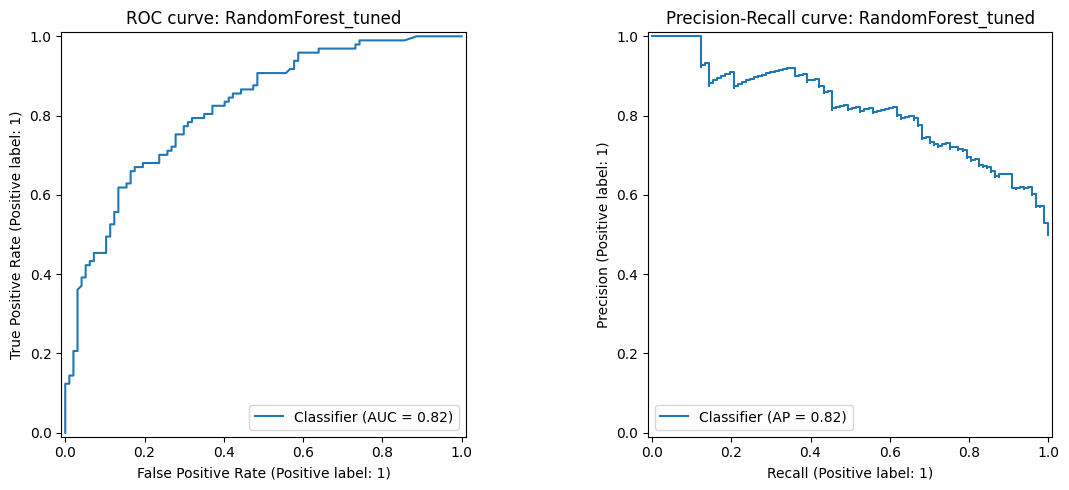

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, best_score, ax=axes[0])
axes[0].set_title(f'ROC curve: {best_model_name}')

PrecisionRecallDisplay.from_predictions(y_test, best_score, ax=axes[1])
axes[1].set_title(f'Precision-Recall curve: {best_model_name}')

plt.tight_layout()
plt.show()

По результатам тюнинга лучшей моделью стала RandomForest_tuned. Она показала на тестовой выборке ROC_AUC = 0.8178, PR_AUC = 0.8177, accuracy = 0.7320 и F1 = 0.7347. По сравнению с baseline RandomForest тюнинг улучшил ROC_AUC с 0.7972 до 0.8178 и PR_AUC с 0.8029 до 0.8177, при почти неизменной accuracy.

Матрица ошибок показывает, что модель допускает сопоставимое число ошибок обоих типов: 27 объектов класса 0 ошибочно отнесены к классу 1 и 25 объектов класса 1 ошибочно отнесены к классу 0. Это говорит об отсутствии выраженного перекоса в сторону одного класса.

Итоговое качество можно считать хорошим для задачи классификации IC50 выше медианы: модель существенно превосходит DummyClassifier и достигает ROC_AUC выше 0.81. При этом у tree-based моделей наблюдается заметный overfit gap, поэтому дальнейшее улучшение качества может потребовать дополнительных молекулярных признаков и более устойчивой регуляризации.

## Важность признаков

Для tree-based моделей используется встроенная feature_importances_. Для линейных моделей используется абсолютное значение коэффициентов. Интерпретация признаков является вспомогательной и требует осторожности.

,feature,importance
0,BCUT2D_MRLOW,0.037470
1,VSA_EState8,0.031319
2,SlogP_VSA5,0.023847
3,VSA_EState4,0.023822
4,BCUT2D_MWLOW,0.022180
5,EState_VSA5,0.019709
6,EState_VSA4,0.018591
7,NHOHCount,0.018293
8,BCUT2D_LOGPHI,0.017897
9,EState_VSA8,0.017815


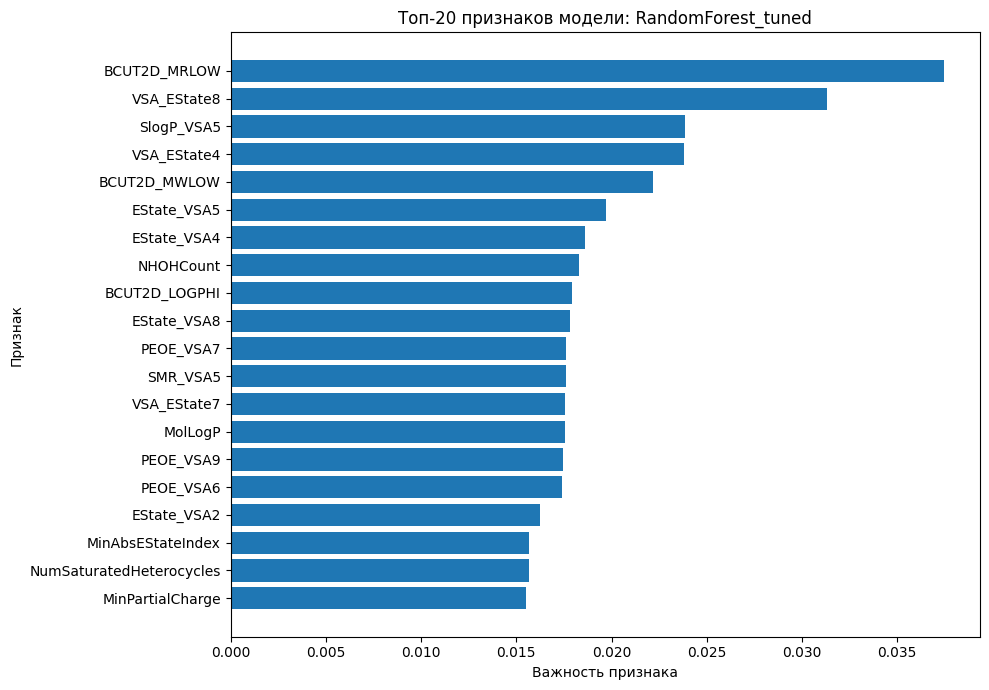

In [58]:
feature_names_best = X_linear.columns if best_feature_set == 'X_linear' else X_tree.columns

final_model = best_model[-1] if isinstance(best_model, Pipeline) else best_model

def plot_importance(importance_df=None):
    if importance_df is not None:
        display(importance_df.head(30))

        plot_imp = importance_df.head(20).iloc[::-1]

        plt.figure(figsize=(10, 7))
        plt.barh(plot_imp['feature'], plot_imp['importance'])
        plt.xlabel('Важность признака')
        plt.ylabel('Признак')
        plt.title(f'Топ-20 признаков модели: {best_model_name}')
        plt.tight_layout()
        plt.show()
    else:
        print('Для выбранной модели нет встроенной важности признаков или коэффициентов.')

importance_df = None

if hasattr(final_model, 'feature_importances_'):
    importance_df = (
        pd.DataFrame({
            'feature': feature_names_best,
            'importance': final_model.feature_importances_
        })
        .sort_values('importance', ascending=False)
        .reset_index(drop=True)
    )

elif hasattr(final_model, 'coef_'):
    importance_df = (
        pd.DataFrame({
            'feature': feature_names_best,
            'coefficient': np.ravel(final_model.coef_)
        })
        .assign(abs_coefficient=lambda x: x['coefficient'].abs())
        .sort_values('abs_coefficient', ascending=False)
        .drop(columns='abs_coefficient')
        .reset_index(drop=True)
    )

plot_importance(importance_df)

## Сохранение модели

In [59]:
os.makedirs(MODELS_DIR, exist_ok=True)

model_path = os.path.join(MODELS_DIR, 'best_IC50_gt_median_classification_model.joblib')

joblib.dump(best_model, model_path)

print(f'Лучшая модель сохранена: {model_path}')

Лучшая модель сохранена: models/best_IC50_gt_median_classification_model.joblib
Таблица результатов сохранена: models/IC50_gt_median_classification_results.csv


## Выводы

В ноутбуке решена задача бинарной классификации: превышает ли значение IC50, mM медианное значение выборки. Порог классификации составил 45.22 mM. Поскольку порог задан по медиане, классы получились полностью сбалансированными: 483 объекта класса 0 и 483 объекта класса 1. Это позволяет интерпретировать accuracy, balanced_accuracy и F1 без сильного искажения из-за дисбаланса классов.

Для сравнения были использованы две группы моделей: линейные модели на X_linear и tree-based модели на X_tree. Основной метрикой выбрана ROC_AUC, так как она оценивает качество ранжирования объектов и не зависит от конкретного порога классификации. Дополнительно анализировались accuracy, balanced_accuracy, precision, recall, F1 и PR_AUC.

### Сравнение baseline-моделей

На кросс-валидации лучший средний ROC_AUC показала модель RandomForest: cv_ROC_AUC = 0.784. Близкие результаты также получили ExtraTrees, SVC_rbf, HistGBM, XGBoost и GradientBoosting. При этом у tree-based моделей наблюдался выраженный overfit_gap_ROC_AUC: train ROC_AUC был близок к 0.99, тогда как CV ROC_AUC находился примерно на уровне 0.77-0.78. Это указывает на риск переобучения, что ожидаемо для небольшой выборки и большого числа молекулярных дескрипторов.

На тестовой выборке среди baseline-моделей лучший ROC_AUC показала LightGBM: ROC_AUC = 0.8095. XGBoost показал лучшие значения accuracy, balanced_accuracy и F1 среди baseline-моделей: accuracy = 0.7423, F1 = 0.7340, ROC_AUC = 0.8065. RandomForest показал одно из лучших значений PR_AUC: PR_AUC = 0.8029. Все основные модели существенно превзошли Dummy_most_frequent, у которого ROC_AUC = 0.5000.

### Результаты тюнинга

Для подбора гиперпараметров были отобраны наиболее перспективные модели: LogisticRegression, SVC_rbf, RandomForest, ExtraTrees, XGBoost и LightGBM. Тюнинг выполнялся по ROC_AUC.

На кросс-валидации лучшие tuned-результаты получили RandomForest_tuned и ExtraTrees_tuned: best_cv_ROC_AUC = 0.7953 и 0.7941 соответственно. На тестовой выборке эти модели также стали лучшими по ROC_AUC:

- RandomForest_tuned: ROC_AUC = 0.8178, PR_AUC = 0.8177, accuracy = 0.7320, F1 = 0.7347;
- ExtraTrees_tuned: ROC_AUC = 0.8167, PR_AUC = 0.8167, accuracy = 0.7371, F1 = 0.7385.

Тюнинг улучшил качество RandomForest по сравнению с baseline: ROC_AUC вырос примерно с 0.7972 до 0.8178. Для ExtraTrees улучшение также заметное: ROC_AUC вырос примерно с 0.7982 до 0.8167. При этом XGBoost_tuned и LightGBM_tuned не дали такого же устойчивого выигрыша по сравнению с лучшими baseline-моделями.

### Финальная модель

Финальная модель выбрана по максимальному ROC_AUC на тестовой выборке. Лучшей моделью стала RandomForest_tuned, обученная на X_tree.

Для RandomForest_tuned получены следующие результаты на тестовой выборке:

- ROC_AUC = 0.8178;
- PR_AUC = 0.8177;
- accuracy = 0.7320;
- balanced_accuracy = 0.7320;
- precision = 0.7273;
- recall = 0.7423;
- F1 = 0.7347.

Confusion matrix показывает достаточно симметричный характер ошибок: 70 объектов класса 0 и 72 объекта класса 1 классифицированы верно, 27 объектов класса 0 ошибочно отнесены к классу 1, а 25 объектов класса 1 ошибочно отнесены к классу 0. Это говорит о том, что модель не имеет выраженного перекоса в сторону одного из классов.

### Интерпретация признаков

Среди наиболее важных признаков RandomForest_tuned оказались BCUT2D_MRLOW, VSA_EState8, SlogP_VSA5, VSA_EState4, BCUT2D_MWLOW, EState_VSA5, EState_VSA4, NHOHCount и другие RDKit-дескрипторы. Эти признаки связаны с молекулярной массой, электронными состояниями, липофильностью, распределением поверхностных вкладов и функциональными группами.

Интерпретация важности признаков является вспомогательной: feature_importances_ показывает вклад признаков в выбранную модель, но не доказывает причинно-химическую связь. Для строгой химической интерпретации требуется отдельный предметный анализ.

### Ограничения и дальнейшие шаги

Качество модели можно считать хорошим для первой классификационной задачи: ROC_AUC около 0.82 и F1 около 0.73 показывают, что модель достаточно хорошо различает соединения с IC50 выше и ниже медианы. Однако задача не решена идеально, а переобучение tree-based моделей остаётся заметным.

Для дальнейшего улучшения можно:

- проверить стабильность финальной модели на других разбиениях данных;
- подобрать порог классификации под конкретную бизнес- или исследовательскую цель, если важнее precision или recall;
- добавить молекулярные fingerprints, например Morgan fingerprints, вместе с RDKit-дескрипторами;
- попробовать ансамбль нескольких сильных моделей, например RandomForest_tuned, ExtraTrees_tuned и XGBoost;
- отдельно анализировать ошибки модели на соединениях около медианного порога IC50, где классы наиболее трудно разделимы.
